# Laboratorium 9 - Sieci Rekurencyjne

Na tym laboratorium zapoznamy się z sieciami rekurencyjnymi - jedną z architektur dedykowanych danym sekwencyjnym. Dla danych sekwencyjnych, jednym z naturalnych podejść do modelowania jest założenie, że przetwarzając n-ty krok, możemy udostępnić modelowi pewną reprezentację historii/pamięci/stanu która w kompaktowy sposób przechowuje informację o "wszystkim co działo się wcześniej". W ten sposób zadania upraszcza sobie często np. modelowanie procesami stochastycznymi (założenie własności Markowa w modelu). W kontekście sieci neuronowych, odpowiednikiem takiego podejścia jest właśnie warstwa rekurencyjna: taka, która w n-tym kroku przetwarza n-te wejście i reprezentacje ukrytą z kroku n-1 (historię/stan/pamięć).

Oczywiście z góry warstwo wspomnieć o fakcie, że architektury rekurencyjne obecnie nie są pierwszym wyborem, w pracach state=of-the-art dominuje mechanizm uwagi. Transformery to obecnie podstawa wszystkiego, co kojarzone z sztuczną inteligencją - w szczególności wszelkiej maści "czatów" opartych o LLM (Large Language Models). Ale ich historia to w pierwszej kolejności dodanie mechanizmu uwagi do sieci rekurencyjnych, a dopiero potem spostrzeżenie, że po dodaniu tego mechanizmu, rekurencja nie jest już w zasadzie konieczna (bardzo znana publikacja *Attention Is All You Need*).

 Na tych laboratoriach przyjrzyjmy się warstwom LSTM - najpopularniejszej wersji architektury czysto rekurencyjnej.

# Zbiory danych

Przeprowadzimy test na dwóch zbiorach danych: klasyczny zbiór do analizy sentymentu tekstów (recenzje IMDB), oraz zbiór audio - rozpoznawanie owadów po wydawanych rzez nich odgłosach.

In [17]:

import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)  

cpu


In [18]:
from tensorflow.keras.datasets import imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz',
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)

# preprocessing: przytnij długość i vocab
VOCAB_SIZE = 10000
MAX_LEN = 300

x_train = [[token if token < VOCAB_SIZE else 2 for token in seq[:MAX_LEN]] for seq in x_train]
x_test  = [[token if token < VOCAB_SIZE else 2 for token in seq[:MAX_LEN]] for seq in x_test]

In [19]:
print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [20]:
#!pip install aeon

In [21]:
from aeon.datasets import load_classification
X, y = load_classification("InsectWingbeat", extract_path="insect_data")

/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_85866/3839978134.py:2: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X, y = load_classification("InsectWingbeat", extract_path="insect_data")


In [22]:
print(type(X))
print(len(X))
print(type(X[0]))
print(X[0].shape)
print(y[:5])
print(set(y))
print(len(set(y)))

<class 'list'>
50000
<class 'numpy.ndarray'>
(200, 7)
['aedes_female' 'aedes_female' 'aedes_female' 'aedes_female'
 'aedes_female']
{np.str_('aedes_male'), np.str_('quinx_male'), np.str_('tarsalis_female'), np.str_('stigma_male'), np.str_('tarsalis_male'), np.str_('fruit_flies'), np.str_('house_flies'), np.str_('stigma_female'), np.str_('quinx_female'), np.str_('aedes_female')}
10


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(y_encoded[:5])
print(le.classes_)

[0 0 0 0 0]
['aedes_female' 'aedes_male' 'fruit_flies' 'house_flies' 'quinx_female'
 'quinx_male' 'stigma_female' 'stigma_male' 'tarsalis_female'
 'tarsalis_male']


# Wczytywanie danych sekwencyjnych

Dla danych sekwencyjnych, przy przetwarzaniu w batchu pojawia się nowa komplikacja: batch musi być możliwy do "spakowania" w tensorze `batch_size x vector_dimension x sequence_length `, podczas gdy sekwencje w zbiorze uczącym nie muszą być jednakowego rozmiaru. Rozwiązaniem jest padding: dopełnianie tensorów zerami do stałej długości.

W problemach klasyfikacyjnych to powoduje jednak nowy problem: chcemy uzyskać reprezentację do klasyfikacji na końcu właściwej sekwencji, nie po przetworzeniu kilu (nastu/dziesięciu/set) dodatkowych wektorów zer. Implementacje warstw rekurencyjnych w torchu oferują nam rozwiązanie w postaci obiektów PackedSequence. Odpowiednimi funkcjami możemy "spakować" zarówno listę sekencji, jak i tensor już wypadowanych danych z podanymi osobno długościami sekwencji. Podanie takiej paczki na wejści warstwy rekurencyjnej gwarantuje, że warstwa zwróci nam swoją reprezentację na poziomie **ostatniego elementu właściwej sekwencji** (nie biorąc pod uwagę paddingu).

In [24]:
import torch

sequences = [[0,1,2,3],
             [0,1],
             [0]]

packed_sequences = torch.nn.utils.rnn.pack_sequence([torch.tensor(seq) for seq in sequences])
print(packed_sequences)

padded_sequences = torch.nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in sequences])
print(padded_sequences)

packed_padded_sequences = torch.nn.utils.rnn.pack_padded_sequence(padded_sequences, [len(s) for s in sequences])
print(packed_padded_sequences)

PackedSequence(data=tensor([0, 0, 0, 1, 1, 2, 3]), batch_sizes=tensor([3, 2, 1, 1]), sorted_indices=None, unsorted_indices=None)
tensor([[0, 0, 0],
        [1, 1, 0],
        [2, 0, 0],
        [3, 0, 0]])
PackedSequence(data=tensor([0, 0, 0, 1, 1, 2, 3]), batch_sizes=tensor([3, 2, 1, 1]), sorted_indices=None, unsorted_indices=None)


# Zadanie 1

Zaimplementuj obiekty Dataset i DataLoader dla naszych zbiorów danych w wariantach zwracających zarówno obiekt PackedSequences, jak i prosty tensor z  wypadowanym zerami batchem.

In [25]:
# zaimplementuj DataLoader z wariantami: Padded sequences i standardowe tensory, dopełnione zerami do równej długości
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_sequence

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.long)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return x, label

def collate_padded(batch):
    sequences, labels = zip(*batch)
    sorted_pairs = sorted(zip(sequences, labels), key=lambda x: len(x[0]), reverse=True)
    sequences, labels = zip(*sorted_pairs)
    lengths = torch.tensor([len(s) for s in sequences])
    padded = pad_sequence(sequences, batch_first=False)
    return padded, lengths, torch.stack(list(labels))

def collate_packed(batch):
    sequences, labels = zip(*batch)
    sorted_pairs = sorted(zip(sequences, labels), key=lambda x: len(x[0]), reverse=True)
    sequences, labels = zip(*sorted_pairs)
    packed = pack_sequence(list(sequences))
    return packed, torch.stack(list(labels))

BATCH_SIZE = 64

train_dataset = SequenceDataset(x_train, y_train)
test_dataset  = SequenceDataset(x_test,  y_test)

train_padded = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_padded)
test_padded  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_padded)

train_packed = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_packed)
test_packed  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_packed)

# Embedding

Warstwy embeddingu są elementem wykorzystywanym przy przetwarzaniu danych, gdzie elementem jest id w pewnym dyskretnym zbiorze obiektów. Przykładowo, dla danych językowych może być to zbiór możliwych słów. Warstwa przyporządkowuje każdemu id jego własny wektor, i zakładamy, że w trakcie uczenia wyuczy się podobieństwa między obiektami.

## Model LSTM

W teorii, warstwy LSTM potrafią zapamiętywać "długoterminowo" a więc to skąd wyciągamy dane nie powinno robić większego problemu. Sprawdźmy czy tak jest w rzeczywistości, implementując wersję prostego eksperymentu - implementując uczenie zarówno z wykorzystaniem obiektów PackedSequence, jak i zwyczajnych tensorów dopełnionych zerami.

Nasz model LSTM musi być przygotowany na wszystkie opisane wersje naszego eksperymentu: dane w postaci sekwencji już w przestrzeni cech i w postaci sekwencji Integerów z embeddingiem w obrębie sieci; wykorzystanie PacekdSequences lub nie.

(**UWAGA:** W przypadku wykorzystania Embeddingu i Packed Sequences jednocześnie, będzie trzeba rozpakować, embedować i spakować jeszcze raz. Obsługiwanie tych czterech wariantów w jednej klasie nie jest praktyczne, potraktuj je raczej jako ćwiczenie.)

In [26]:
import torch.nn as nn

class LSTMNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 bidirectional=False, embed=False, vocab_size=None, packed=False, dropout=0.3):
        super().__init__()
        self.embed = embed
        self.packed = packed
        self.bidirectional = bidirectional

        if embed:
            self.embedding = nn.Embedding(vocab_size, input_size, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=False
        )

        fc_input = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Linear(fc_input, num_classes)

    def forward(self, x, lengths=None):
        if self.embed:
            if self.packed:
                data, batch_sizes, sorted_indices, unsorted_indices = x
                data = self.embedding(data)
                x = torch.nn.utils.rnn.PackedSequence(data, batch_sizes, sorted_indices, unsorted_indices)
            else:
                x = self.embedding(x)

        output, (h_n, c_n) = self.lstm(x)

        if self.bidirectional:
            h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h = h_n[-1]

        return self.fc(h)

## Uczenie

Pętla ucząca dla modelu LSTM będzie analogiczna do znanych nam wcześniej

In [53]:
# Zaimplementuj pętlę uczącą. Możesz wykorzystać kod z wcześniejszych laboratoriów,
from torch.optim import Adam
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def train(model, train_loader, val_loader, epochs=5, lr=1e-3, packed=False, device='cpu'):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]", leave=False)
        for batch in pbar:
            if packed:
                x, labels = batch
                lengths = None
            else:
                x, lengths, labels = batch
                x = x.to(device)

            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(x, lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]", leave=False):
                if packed:
                    x, labels = batch
                    lengths = None
                else:
                    x, lengths, labels = batch
                    x = x.to(device)

                labels = labels.to(device)
                outputs = model(x, lengths)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc  = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    return history


def plot_histories(histories, labels):
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    for history, label, color in zip(histories, labels, colors):
        epochs = range(1, len(history['train_loss']) + 1)
        axes[0].plot(epochs, history['train_loss'], '--', color=color, label=f'{label} train')
        axes[0].plot(epochs, history['val_loss'],   '-',  color=color, label=f'{label} val')
        axes[1].plot(epochs, history['train_acc'],  '--', color=color, label=f'{label} train')
        axes[1].plot(epochs, history['val_acc'],    '-',  color=color, label=f'{label} val')

    axes[0].set_title('Loss');     axes[0].legend(); axes[0].set_xlabel('Epoch')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()


def plot_single(history, label, color='tab:blue'):
    color = color
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], '--', color=color, label='train')
    axes[0].plot(epochs, history['val_loss'],   '-',  color=color, label='val')
    axes[1].plot(epochs, history['train_acc'],  '--', color=color, label='train')
    axes[1].plot(epochs, history['val_acc'],    '-',  color=color, label='val')
    axes[0].set_title(f'{label} — Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
    axes[1].set_title(f'{label} — Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()

def print_summary_table(histories, labels):
    print(f"\n{'Model':<20} {'Train Loss':>12} {'Val Loss':>12} {'Train Acc':>12} {'Val Acc':>12} {'Gap Acc':>12}")
    print("-" * 82)
    for history, label in zip(histories, labels):
        tl = history['train_loss'][-1]
        vl = history['val_loss'][-1]
        ta = history['train_acc'][-1]
        va = history['val_acc'][-1]
        gap = ta - va
        print(f"{label:<20} {tl:>12.4f} {vl:>12.4f} {ta:>12.4f} {va:>12.4f} {gap:>12.4f}")

## Zadanie 2

Przeprowadź uczenie modelu LSTM na zadanym zbiorze i porównaj następujące podejścia:

*   LSTM, dane z paddingiem do długości najdłuższej sekwencji w batchu
*   Jak wyżej, ale Bidirectional
*   LSTM (nie bidirectional) z wykorzystaniem obiektów PaddedSequences

Wariant 1: LSTM z paddingiem


Epoch 1/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 | Train loss: 0.6945, acc: 0.5003 | Val loss: 0.6934, acc: 0.5045


Epoch 2/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 9/10 | Train loss: 0.4988, acc: 0.7432 | Val loss: 0.8270, acc: 0.6419


Epoch 10/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 | Train loss: 0.4868, acc: 0.7516 | Val loss: 0.8425, acc: 0.6337


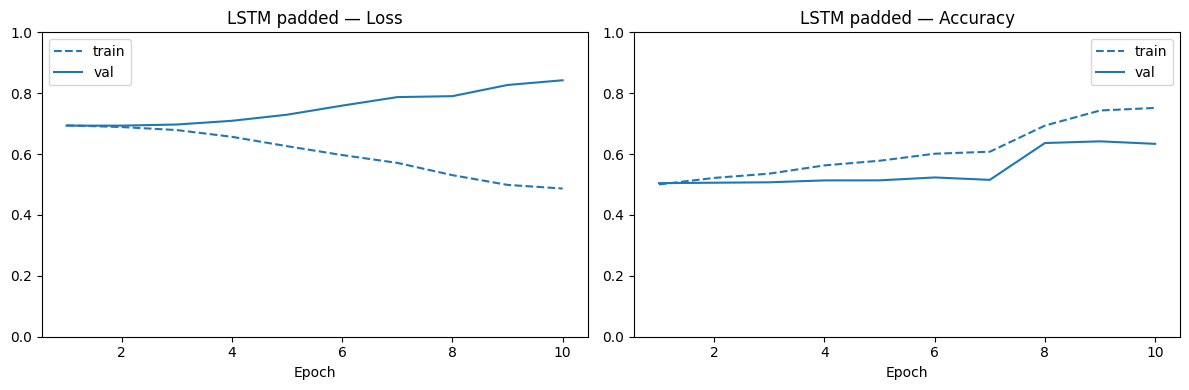

Wariant 2: Bidirectional LSTM z paddingiem


Epoch 1/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 | Train loss: 0.6636, acc: 0.5854 | Val loss: 0.5968, acc: 0.6942


Epoch 2/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 9/10 | Train loss: 0.2429, acc: 0.9127 | Val loss: 0.5435, acc: 0.7979


Epoch 10/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 | Train loss: 0.1971, acc: 0.9298 | Val loss: 0.5442, acc: 0.8009


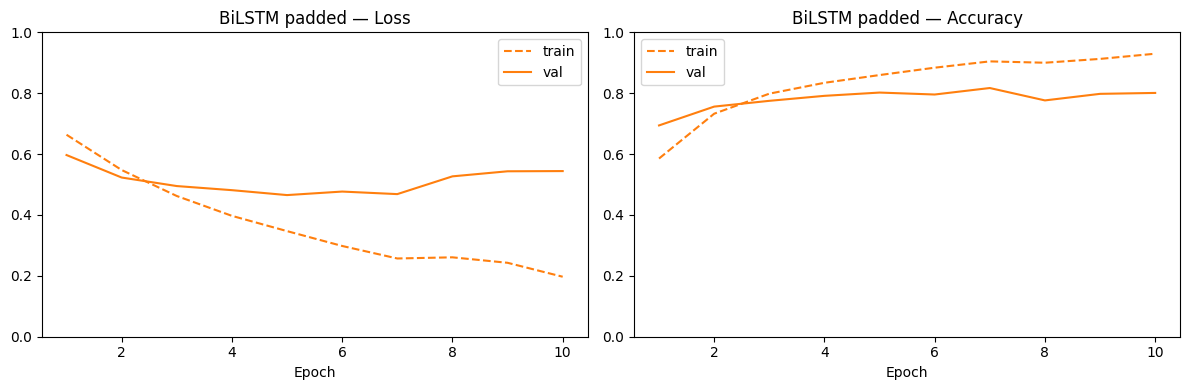

Wariant 3: LSTM z PackedSequence


Epoch 1/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 | Train loss: 0.6543, acc: 0.5971 | Val loss: 0.6021, acc: 0.6949


Epoch 2/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 9/10 | Train loss: 0.1708, acc: 0.9397 | Val loss: 0.4226, acc: 0.8479


Epoch 10/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 | Train loss: 0.1475, acc: 0.9493 | Val loss: 0.4673, acc: 0.8476


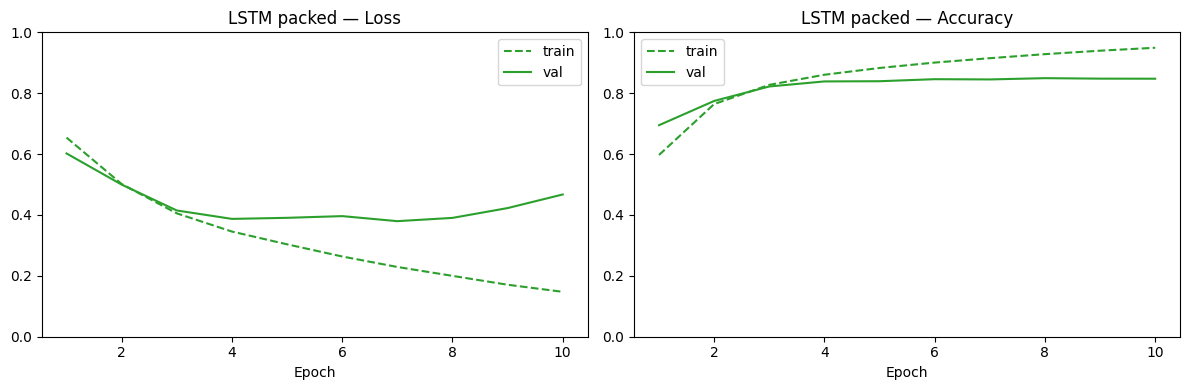

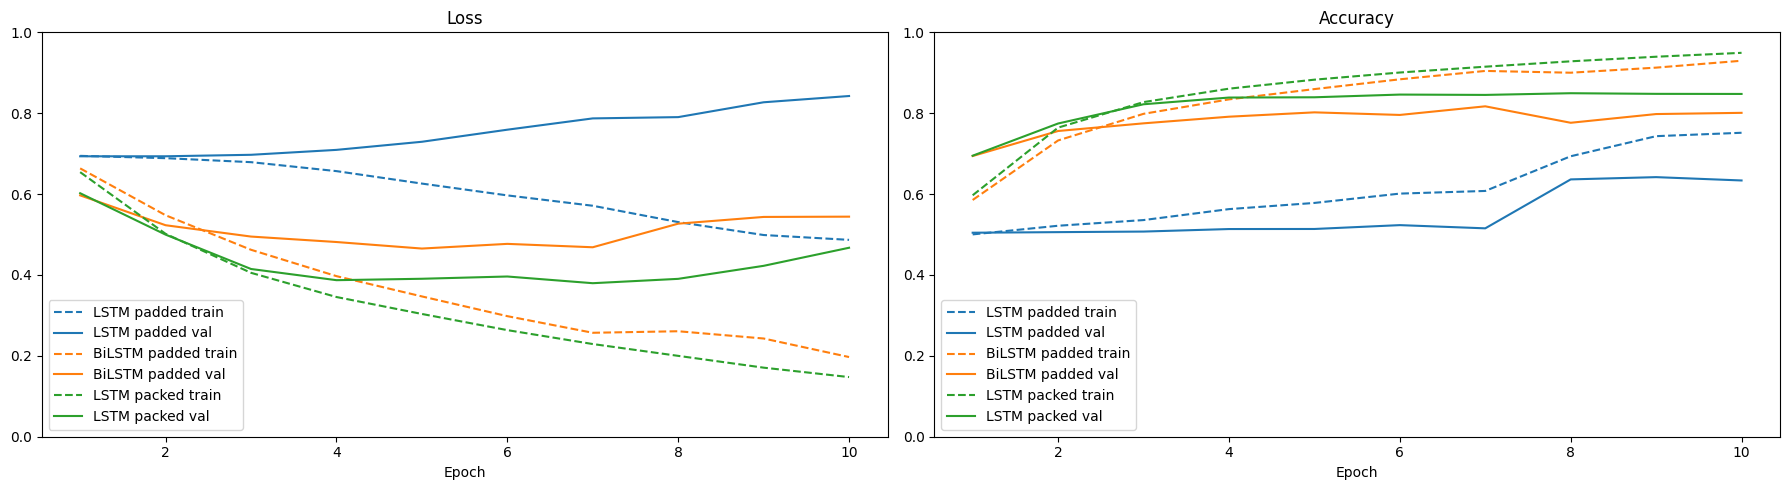


Model                  Train Loss     Val Loss    Train Acc      Val Acc      Gap Acc
----------------------------------------------------------------------------------
LSTM padded                0.4868       0.8425       0.7516       0.6337       0.1180
BiLSTM padded              0.1971       0.5442       0.9298       0.8009       0.1288
LSTM packed                0.1475       0.4673       0.9493       0.8476       0.1017


In [ ]:
# testy
EMBED_DIM   = 64 
HIDDEN_SIZE = 32
NUM_CLASSES = 2
EPOCHS = 10

print("=" * 60)
print("Wariant 1: LSTM z paddingiem")
print("=" * 60)
model1 = LSTMNet(EMBED_DIM, HIDDEN_SIZE, 1, NUM_CLASSES, embed=True, vocab_size=VOCAB_SIZE)
h1 = train(model1, train_padded, test_padded, epochs=EPOCHS, packed=False)
plot_single(h1, 'LSTM padded')

print("=" * 60)
print("Wariant 2: Bidirectional LSTM z paddingiem")
print("=" * 60)
model2 = LSTMNet(EMBED_DIM, HIDDEN_SIZE, 1, NUM_CLASSES, embed=True, vocab_size=VOCAB_SIZE, bidirectional=True)
h2 = train(model2, train_padded, test_padded, epochs=EPOCHS, packed=False)
plot_single(h2, 'BiLSTM padded', color='tab:orange')

print("=" * 60)
print("Wariant 3: LSTM z PackedSequence")
print("=" * 60)
model3 = LSTMNet(EMBED_DIM, HIDDEN_SIZE, 1, NUM_CLASSES, embed=True, vocab_size=VOCAB_SIZE, packed=True)
h3 = train(model3, train_packed, test_packed, epochs=EPOCHS, packed=True)
plot_single(h3, 'LSTM packed', color='tab:green')

plot_histories([h1, h2, h3], ['LSTM padded', 'BiLSTM padded', 'LSTM packed'])
print_summary_table([h1, h2, h3], ['LSTM padded', 'BiLSTM padded', 'LSTM packed'])

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

class InsectDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return x, label

MAX_FEATURES = 22 

def collate_insect(batch):
    sequences, labels = zip(*batch)
    padded = torch.zeros(len(sequences), 200, MAX_FEATURES)
    for i, x in enumerate(sequences):
        padded[i, :, :x.shape[1]] = x
    padded = padded.permute(1, 0, 2)
    return padded, torch.stack(list(labels))

train_insect = DataLoader(InsectDataset(X_train, y_train), batch_size=64, shuffle=True,  collate_fn=collate_insect)
test_insect  = DataLoader(InsectDataset(X_test,  y_test),  batch_size=64, shuffle=False, collate_fn=collate_insect)

In [55]:
def train(model, train_loader, val_loader, epochs=5, lr=1e-3, packed=False, simple=False, device='cpu'):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]", leave=False)
        for batch in pbar:
            if simple or packed:
                x, labels = batch
                lengths = None
            else:
                x, lengths, labels = batch
                x = x.to(device)

            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(x, lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]", leave=False):
                if simple or packed:
                    x, labels = batch
                    lengths = None
                else:
                    x, lengths, labels = batch
                    x = x.to(device)

                labels = labels.to(device)
                outputs = model(x, lengths)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc  = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    return history

Wariant 1: LSTM (Insect)


Epoch 1/10 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1/10 | Train loss: 2.3033, acc: 0.0986 | Val loss: 2.3038, acc: 0.1021


Epoch 2/10 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 9/10 | Train loss: 2.2023, acc: 0.1860 | Val loss: 2.1610, acc: 0.2120


Epoch 10/10 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 10/10 | Train loss: 2.1288, acc: 0.2080 | Val loss: 1.8455, acc: 0.2928


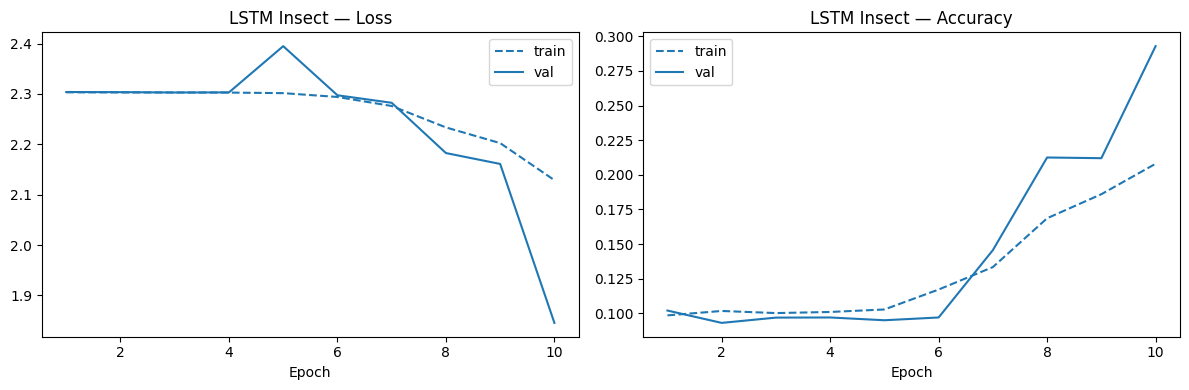

Wariant 2: Bidirectional LSTM (Insect)


Epoch 1/10 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1/10 | Train loss: 1.6101, acc: 0.3977 | Val loss: 1.1600, acc: 0.5569


Epoch 2/10 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 9/10 | Train loss: 0.7224, acc: 0.7048 | Val loss: 0.7899, acc: 0.6866


Epoch 10/10 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 10/10 | Train loss: 0.7110, acc: 0.7107 | Val loss: 0.7716, acc: 0.6897


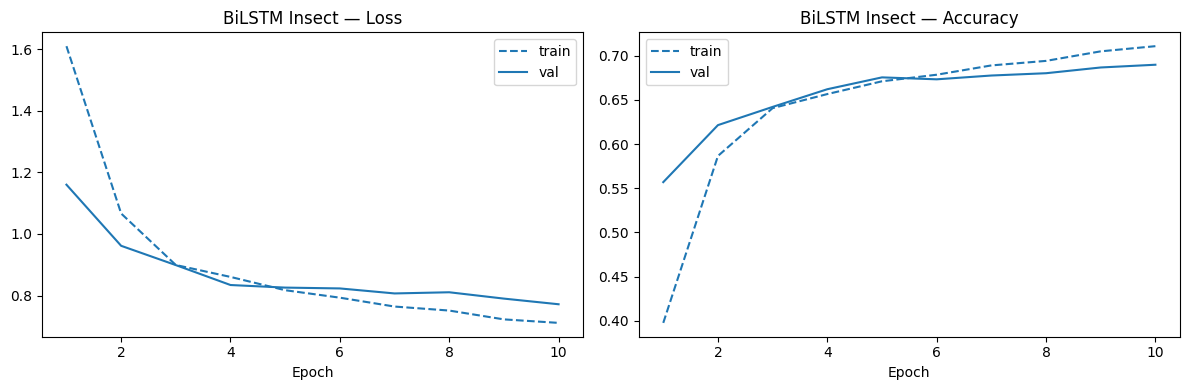

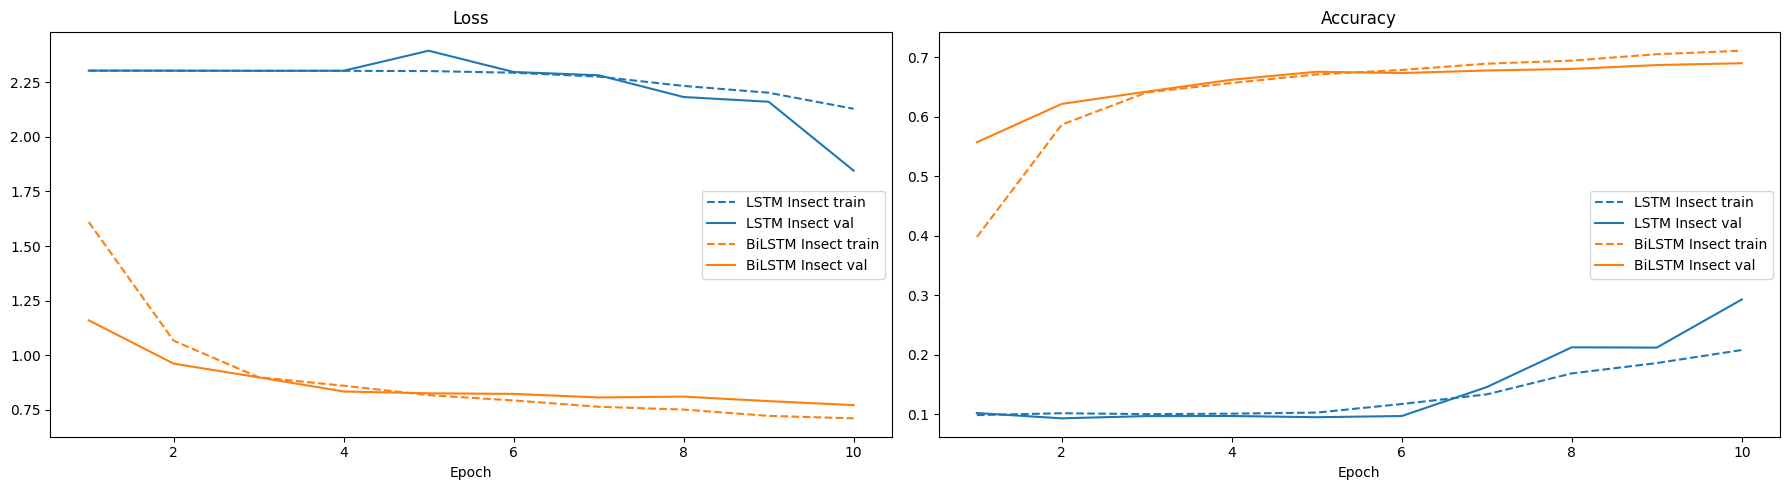


Model                  Train Loss     Val Loss    Train Acc      Val Acc      Gap Acc
----------------------------------------------------------------------------------
LSTM Insect                2.1288       1.8455       0.2080       0.2928      -0.0848
BiLSTM Insect              0.7110       0.7716       0.7107       0.6897       0.0210


In [57]:
HIDDEN_SIZE_INSECT = 64
EPOCHS_INSECT = 10

print("=" * 60)
print("Wariant 1: LSTM (Insect)")
print("=" * 60)
model_i1 = LSTMNet(input_size=22, hidden_size=HIDDEN_SIZE_INSECT, num_layers=1, num_classes=10, embed=False)
h_i1 = train(model_i1, train_insect, test_insect, epochs=EPOCHS_INSECT, simple=True)
plot_single(h_i1, 'LSTM Insect')

print("=" * 60)
print("Wariant 2: Bidirectional LSTM (Insect)")
print("=" * 60)
model_i2 = LSTMNet(input_size=22, hidden_size=HIDDEN_SIZE_INSECT, num_layers=1, num_classes=10, embed=False, bidirectional=True)
h_i2 = train(model_i2, train_insect, test_insect, epochs=EPOCHS_INSECT, simple=True)
plot_single(h_i2, 'BiLSTM Insect')

plot_histories([h_i1, h_i2], ['LSTM Insect', 'BiLSTM Insect'])
print_summary_table([h_i1, h_i2], ['LSTM Insect', 'BiLSTM Insect'])

# Zadanie 3

Dla modelu językowego, dokonaj wizualizacji embeddingów 10 przykładowych słów. Dobierz słowa samodzielnie tak, aby pokazać, że embedding częściowo (ale prwadopodobnie nie idealnie) oddają relacje semantyczne. Możesz wykorzystać gotowe metody redukcji wymiarowości np. z scikit-learn aby umieścić embeddingi w przestrzeni dwuwymiarowej.

Ponieważ zbiór pobierany z tf.keras jest już reprezentowany w postaci list liczb całkowitych, bedziesz korzystać ze słownika indeksów również dostępnego w tf.keras:

In [52]:
word_idx = imdb.get_word_index(
    path='imdb_word_index.json'
)
print(word_idx["good"])

49


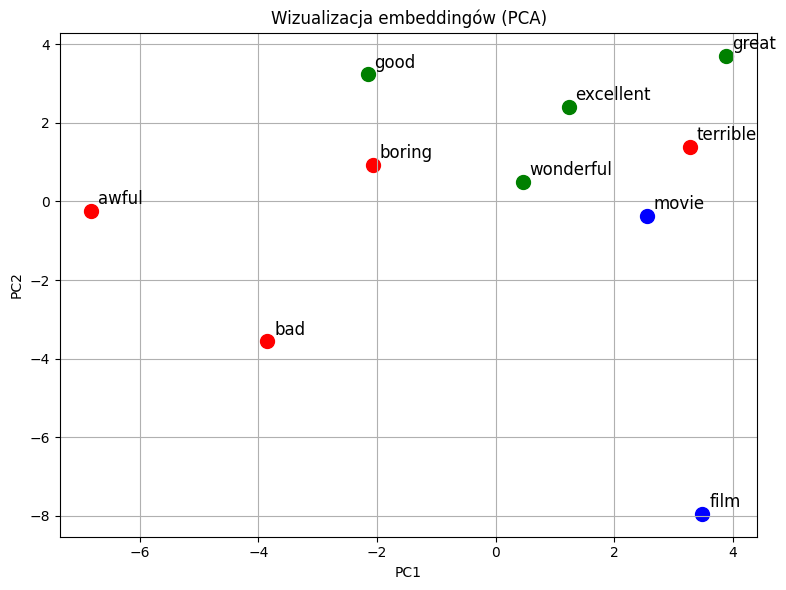

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# słownik z IMDB ma offset +3 (index_from=3)
word_index = imdb.get_word_index()
word_index = {word: idx + 3 for word, idx in word_index.items()}

# 10 słów w dwóch semantycznych grupach
words = ['good', 'great', 'excellent', 'wonderful',
         'bad',  'awful', 'terrible',  'boring',
         'film', 'movie']

# wyciągnij wektory z warstwy embedding modelu1
embedding_weights = model1.embedding.weight.detach().cpu().numpy()

vectors = []
valid_words = []
for word in words:
    idx = word_index.get(word)
    if idx is not None and idx < VOCAB_SIZE:
        vectors.append(embedding_weights[idx])
        valid_words.append(word)

vectors = np.array(vectors)

# redukcja do 2D przez PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# wykres
plt.figure(figsize=(8, 6))
colors = ['green'] * 4 + ['red'] * 4 + ['blue'] * 2
for i, (word, (x, y)) in enumerate(zip(valid_words, coords)):
    plt.scatter(x, y, color=colors[i], s=100)
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=12)

plt.title("Wizualizacja embeddingów (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()